# TaikoNation-style preprocessing (on a TJA chart)

Replicates the data preparation from *TaikoNation: Patterning-focused Chart Generation for Rhythm Action Games* (Halina & Guzdial, FDG 2021) and its reference code in `TaikoNationV1/`.

| step | TaikoNation source | output |
|---|---|---|
| 1. chop audio into 23 ms chunks | `output/chop_song.py` | list of chunks |
| 2. per chunk: Blackman-Harris-62 window → \|FFT\| → 80 mel bands (27.5 Hz–16 kHz) → `log(x + 1e-16)` | `output/output.py::analyze_song` (Essentia) | `(n_frames, 80)` float32 |
| 3. chart → one 7-class one-hot row per 23 ms frame | not included in the repo (the converter was never published) | `(n_frames, 7)` int32 |
| 4. sliding windows: 16 audio frames + 12 note frames + 3 all-ones placeholder rows → 4×7 target | `model.py::preprocess` | `X (N, 1385)`, `Y (N, 4, 7)` |

**Differences from the original**
- **Chart input is `.tja`, not `.osu`**, so a small TJA parser is included. Its note codes map onto TaikoNation's classes.
- **Essentia isn't required.** Windowing, Spectrum and MelBands are reimplemented in numpy. The implementation was checked against `essentia==2.1b6` and matches to about 1e-4 in log-mel on even-length chunks.
- **The original pipeline has two ordering bugs, and they are fixed by default.** `chop_song.py` never exports the 23–46 ms chunk and duplicates the final chunk. `analyze_song` reads the chunk files in `os.listdir()` order, which on Windows is lexicographic (`1, 10, 100, 1000, …`). The shipped `input_songs/*.npy` are stored in this scrambled order; see the last section. Set `REPLICATE_BUGS = True` to reproduce the original behaviour exactly.

In [1]:
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ---- config ----
SONG      = Path("YES or YES.ogg")
CHART     = Path("YES or YES.tja")
COURSE    = "oni"      # TaikoNation trained on high-difficulty charts only
BRANCH    = "M"        # which branch to keep if the chart uses #BRANCHSTART
OUT_DIR   = Path("out")

SR        = 44100      # Essentia MonoLoader(sampleRate=44100)
FRAME_MS  = 23         # ≈ a 1/64 note at 163 BPM
N_MELS    = 80
MEL_LO, MEL_HI = 27.5, 16000.0
LOG_EPS   = 1e-16

REPLICATE_BUGS = False # True = reproduce chop_song/listdir quirks of the original
NORMALIZE      = False # paper says per-band zero-mean/unit-var, but the shipped data is NOT normalized
SEED           = 0     # original drops a random sample from odd-length chunks

CLASSES = ["none", "don", "ka", "DON", "KA", "drumroll", "denden"]

## 1. Load and chop the audio
The original used pydub to slice the mp3 by milliseconds, and each chunk was then loaded as 44.1 kHz mono. Here the whole file is decoded once with ffmpeg, and the chunks are cut at the sample indices pydub would use (`int(ms * sr / 1000)`), which gives 1014 or 1015 samples per chunk.

In [2]:
def load_mono(path, sr=SR):
    raw = subprocess.run(
        ["ffmpeg", "-v", "error", "-i", str(path), "-ac", "1", "-ar", str(sr), "-f", "f32le", "-"],
        capture_output=True, check=True).stdout
    return np.frombuffer(raw, dtype=np.float32)


def chunk_bounds_ms(duration_ms, replicate_bugs=False):
    '''(start_ms, end_ms) of each 23 ms chunk, in the order the features are stored.'''
    if not replicate_bugs:
        n = int(np.ceil(duration_ms / FRAME_MS))
        return [(k * FRAME_MS, min((k + 1) * FRAME_MS, duration_ms)) for k in range(n)]

    # chop_song.py: chunk 1 = [0,23), then i=2,3,... = [23i, 23i+23) -> [23,46) is skipped;
    # the final partial chunk is exported twice ("cap it off")
    bounds = [(0, FRAME_MS)]
    i = 2
    while True:
        a, b = FRAME_MS * i, FRAME_MS * i + FRAME_MS
        bounds.append((min(a, duration_ms), min(b, duration_ms)))
        i += 1
        if b > duration_ms:
            break
    bounds.append(bounds[-1])
    # analyze_song iterates os.listdir(), which is lexicographic on Windows: "x 1.wav", "x 10.wav", ...
    order = sorted(range(len(bounds)), key=lambda k: f"{SONG.stem} {k + 1}.wav")
    return [bounds[k] for k in order]


audio = load_mono(SONG)
duration_ms = len(audio) / SR * 1000
bounds = chunk_bounds_ms(duration_ms, REPLICATE_BUGS)
chunks = [audio[int(a * SR / 1000):int(b * SR / 1000)] for a, b in bounds]
print(f"{duration_ms / 1000:.2f} s -> {len(chunks)} chunks, lengths {sorted(set(map(len, chunks)))[:4]} ...")

105.65 s -> 4594 chunks, lengths [700, 1014, 1015] ...


## 2. Per-chunk log-mel features
This reproduces the three Essentia algorithms from `create_analyzers()`:
- **`Windowing(type='blackmanharris62')`**: a 3-term Blackman-Harris window, scaled so it sums to 2 and rotated to zero phase. The window adapts to the chunk length, so the configured `size=1024` has no effect.
- **Odd-length chunks**: one random sample is deleted, which is what the original does after windowing.
- **`Spectrum`**: |rfft| of the chunk.
- **`MelBands`** with its defaults: an HTK mel scale, triangles built in the mel domain, each filter normalized to unit sum, and applied to the power spectrum.

In [3]:
def hz_to_mel(f):
    return 2595.0 * np.log10(1.0 + f / 700.0)


def blackmanharris62(n):
    a = 2 * np.pi * np.arange(n) / (n - 1)
    w = 0.44959 - 0.49364 * np.cos(a) + 0.05677 * np.cos(2 * a)
    return w * 2.0 / w.sum()


def mel_filterbank(n_bins, sr=SR, n_mels=N_MELS, lo=MEL_LO, hi=MEL_HI):
    edges = np.linspace(hz_to_mel(lo), hz_to_mel(hi), n_mels + 2)
    bin_mel = hz_to_mel(np.arange(n_bins) * sr / 2 / (n_bins - 1))
    fb = np.zeros((n_mels, n_bins))
    for i in range(n_mels):
        l, c, r = edges[i:i + 3]
        fb[i] = np.clip(np.minimum((bin_mel - l) / (c - l), (r - bin_mel) / (r - c)), 0, None)
        fb[i] /= fb[i].sum()
    return fb


_windows, _filterbanks = {}, {}
rng = np.random.default_rng(SEED)

def chunk_to_mel(x):
    n = len(x)
    if n < 4:  # Essentia would throw here; the original appends zeros, which log() turns into -36.84
        return np.zeros(N_MELS)
    if n not in _windows:
        _windows[n] = blackmanharris62(n)
    y = np.roll(x * _windows[n], -(n // 2))  # zero-phase, as Essentia outputs it
    if n % 2:
        y = np.delete(y, rng.integers(n))
    mag = np.abs(np.fft.rfft(y))
    if len(mag) not in _filterbanks:
        _filterbanks[len(mag)] = mel_filterbank(len(mag))
    return _filterbanks[len(mag)] @ (mag ** 2)


song_feats = np.log(np.array([chunk_to_mel(c) for c in chunks]) + LOG_EPS).astype(np.float32)
if NORMALIZE:
    # for a real dataset, compute these statistics on the training split only
    song_feats = (song_feats - song_feats.mean(0)) / (song_feats.std(0) + 1e-8)

print(song_feats.shape, song_feats.dtype, f"min {song_feats.min():.2f}  mean {song_feats.mean():.2f}  max {song_feats.max():.2f}")

(4594, 80) float32 min -36.84  mean -10.60  max -0.67


## 3. Parse the TJA chart

A note's time is `-OFFSET + elapsed beats × 60 / BPM`. Each measure's note characters split the measure evenly. The parser supports `#BPMCHANGE` (including mid-measure), `#MEASURE`, `#DELAY` and branches (it keeps `BRANCH`). Visual-only commands such as `#SCROLL` and `#GOGOSTART` are ignored.

TJA codes map onto TaikoNation's 7 classes. The index order is the one used by TaikoNation's code and data, which differs from the order the paper lists them in.

| class | TaikoNation | TJA |
|---|---|---|
| 0 | no note | `0` |
| 1 | small don | `1` |
| 2 | small ka | `2` |
| 3 | big DON | `3`, `A` |
| 4 | big KA | `4`, `B` |
| 5 | drumroll (every frame of the span is marked) | `5`, `6` … `8` |
| 6 | denden / spinner (every frame of the span is marked) | `7`, `9` (balloon) … `8` |

In [4]:
COURSE_ALIASES = {"0": "easy", "1": "normal", "2": "hard", "3": "oni", "4": "edit", "ura": "edit"}
ONSET = {"1": 1, "2": 2, "3": 3, "A": 3, "4": 4, "B": 4}
ROLL_START = {"5": 5, "6": 5, "7": 6, "9": 6}


def parse_tja(path, course=COURSE, branch=BRANCH):
    '''Return (meta, events); events = [(start_s, class, end_s or None)].'''
    header, courses, cur = {}, {}, None
    body = None
    for line in Path(path).read_text(encoding="utf-8-sig").splitlines():
        line = line.split("//")[0].strip()
        if not line:
            continue
        if body is not None:
            if line.upper().startswith("#END"):
                courses[cur].setdefault("body", body)
                body = None
            else:
                body.append(line)
        elif line.upper().startswith("#START"):
            body = []
        elif ":" in line:
            k, v = (s.strip() for s in line.split(":", 1))
            if k.upper() == "COURSE":
                cur = COURSE_ALIASES.get(v.lower(), v.lower())
                courses.setdefault(cur, {"meta": {}})
            elif cur is None:
                header[k.upper()] = v
            else:
                courses[cur]["meta"][k.upper()] = v

    if course not in courses:
        raise KeyError(f"course {course!r} not in {list(courses)}")
    meta = {**header, **courses[course]["meta"]}

    # flatten the body into tokens, dropping lines from branches we don't want
    tokens, active = [], None
    for line in courses[course]["body"]:
        if line.startswith("#"):
            cmd, _, arg = line[1:].partition(" ")
            cmd = cmd.upper()
            if cmd == "BRANCHSTART":
                active = "?"
            elif cmd in ("N", "E", "M"):
                active = cmd
            elif cmd == "BRANCHEND":
                active = None
            elif active in (None, "?", branch):
                tokens.append(("cmd", cmd, arg.strip()))
            continue
        if active not in (None, branch):
            continue
        for ch in line:
            if ch == ",":
                tokens.append(("bar",))
            elif not ch.isspace():
                tokens.append(("note", ch))

    bpm, t, beats = float(meta["BPM"]), -float(meta.get("OFFSET", 0)), 4.0
    events, roll = [], None
    measure = []

    def apply(cmd, arg):
        nonlocal bpm, t, beats
        if cmd == "BPMCHANGE":
            bpm = float(arg)
        elif cmd == "DELAY":
            t += float(arg)
        elif cmd == "MEASURE":
            num, den = arg.split("/")
            beats = 4.0 * float(num) / float(den)

    for tok in tokens:
        if tok[0] != "bar":
            measure.append(tok)
            continue
        # #MEASURE applies to the whole bar it opens
        for m in measure:
            if m[0] == "cmd" and m[1] == "MEASURE":
                apply(*m[1:])
        n_notes = sum(m[0] == "note" for m in measure)
        if n_notes == 0:
            for m in measure:
                if m[1] != "MEASURE":
                    apply(*m[1:])
            t += beats * 60.0 / bpm
        for m in (measure if n_notes else []):
            if m[0] == "cmd":
                if m[1] != "MEASURE":
                    apply(*m[1:])
                continue
            ch = m[1]
            if roll is not None and ch == "8":
                events.append((roll[0], roll[1], t))
                roll = None
            elif roll is None and ch in ROLL_START:
                roll = (t, ROLL_START[ch])
            elif roll is None and ch in ONSET:
                events.append((t, ONSET[ch], None))
            t += beats / n_notes * 60.0 / bpm
        measure = []
    return meta, events


meta, events = parse_tja(CHART)
print({k: meta[k] for k in ("TITLE", "BPM", "OFFSET", "LEVEL") if k in meta})
print(len(events), "events; first 5:", [(round(s, 3), CLASSES[c], e and round(e, 3)) for s, c, e in events[:5]])

{'TITLE': 'YES or YES', 'BPM': '138', 'OFFSET': '-1.815', 'LEVEL': '6'}
413 events; first 5: [(1.815, 'don', None), (2.25, 'ka', None), (2.467, 'don', None), (2.902, 'don', None), (3.119, 'ka', None)]


## 4. Events → 23 ms one-hot frames
Frame `k` covers `[23k, 23k+23)` ms, the same span as audio chunk `k`. Labels always stay on the true time grid; with `REPLICATE_BUGS`, only the audio gets misordered, as in the original. TaikoNation's chart files end at the last note and are zero-padded to the song length at load time. Here the padding happens straight away.

In [5]:
def events_to_frames(events, n_frames):
    labels = np.zeros(n_frames, dtype=np.int64)
    dropped = 0
    for start, cls, end in events:
        f0 = int(start * 1000 // FRAME_MS)
        if not 0 <= f0 < n_frames:
            dropped += 1
            continue
        if end is None:
            if labels[f0]:
                dropped += 1   # two onsets within 23 ms
            else:
                labels[f0] = cls
        else:
            f1 = min(int(end * 1000 // FRAME_MS), n_frames - 1)
            span = labels[f0:f1 + 1]
            span[span == 0] = cls
    return np.eye(len(CLASSES), dtype=np.int32)[labels], dropped


note_frames, dropped = events_to_frames(events, len(song_feats))
counts = note_frames.sum(0)
print(note_frames.shape, "dropped:", dropped)
for name, c in zip(CLASSES, counts):
    print(f"  {name:9s} {c:6d}  {c / counts.sum():6.2%}")

(4594, 7) dropped: 0
  none        4026  87.64%
  don          242   5.27%
  ka           152   3.31%
  DON           15   0.33%
  KA             0   0.00%
  drumroll     120   2.61%
  denden        39   0.85%


## 5. Sliding windows, as in `model.py::preprocess`
This is a vectorized port of the original loops. For every audio frame `j`:
- `song_input` = audio frames `j, j-1, …, j-15` (newest first) → 16×80
- `note_input` = note frames `j, …, j-11`, then 3 rows of ones → 15×7
- `X` = `concat(song_input.flatten(), note_input.flatten())` → 1385
- `Y` = note frames `j-12, …, j-15` → 4×7

As in the original, the "known" notes are the newest 12 frames and the target is the **oldest** 4. That's the reverse of the paper's description, "previous notes → next 4". A literal port of the original loop is included below to check the vectorized version.

In [6]:
def make_windows(song, notes):
    n = len(song)
    notes = notes[:n]
    notes = np.vstack([notes, np.zeros((n - len(notes), notes.shape[1]), notes.dtype)])
    song_p = np.vstack([np.zeros((15, song.shape[1]), song.dtype), song])
    note_p = np.vstack([np.zeros((15, notes.shape[1]), notes.dtype), notes])
    idx = np.arange(n)[:, None] + 15 - np.arange(16)[None, :]   # row k -> frame j-k
    song_win, note_win = song_p[idx], note_p[idx].astype(np.float32)
    note_in = np.concatenate([note_win[:, :12], np.ones((n, 3, notes.shape[1]), np.float32)], axis=1)
    X = np.concatenate([song_win.reshape(n, -1), note_in.reshape(n, -1)], axis=1)
    Y = note_win[:, 12:16]
    return X, Y


def make_windows_reference(song_data, note_data, n_check):
    '''literal port of the loops in TaikoNationV1/model.py (first n_check frames only).'''
    pad = len(song_data) - len(note_data)
    note_data = np.append(note_data, np.zeros((pad + 16, 7)), axis=0)
    X, Y = [], []
    for j in range(n_check):
        song_input, note_input, out = [], [], []
        for k in range(16):
            if j - k < 0:
                song_input.append(np.zeros(80))
                if k < 12: note_input.append(np.zeros(7))
                elif k != 15: note_input.append(np.ones(7))
                if k > 11: out.append(np.zeros(7))
            else:
                song_input.append(song_data[j - k])
                if k < 12: note_input.append(note_data[j - k])
                elif k != 15: note_input.append(np.ones(7))
                if k > 11: out.append(note_data[j - k])
        X.append(np.concatenate([np.array(song_input).flatten(), np.array(note_input).flatten()]))
        Y.append(np.concatenate(out).reshape(4, 7))
    return np.array(X), np.array(Y)


X, Y = make_windows(song_feats, note_frames)
Xr, Yr = make_windows_reference(song_feats, note_frames, 400)
assert np.allclose(X[:400], Xr) and np.allclose(Y[:400], Yr)
print("X", X.shape, X.dtype, "| Y", Y.shape, Y.dtype, "| matches reference loop")

X (4594, 1385) float32 | Y (4594, 4, 7) float32 | matches reference loop


## 6. Sanity checks
- **Alignment.** Spectral flux (summed positive frame-to-frame log-mel increase) should be clearly higher on onset frames than on average. On TaikoNation's own data, this ratio is about 2.0 after undoing the lexicographic scramble and about 1.0 as shipped.
- **Plot.** A few seconds of the log-mel spectrogram with the note frames overlaid.

flux at onset frames / mean flux: 3.01


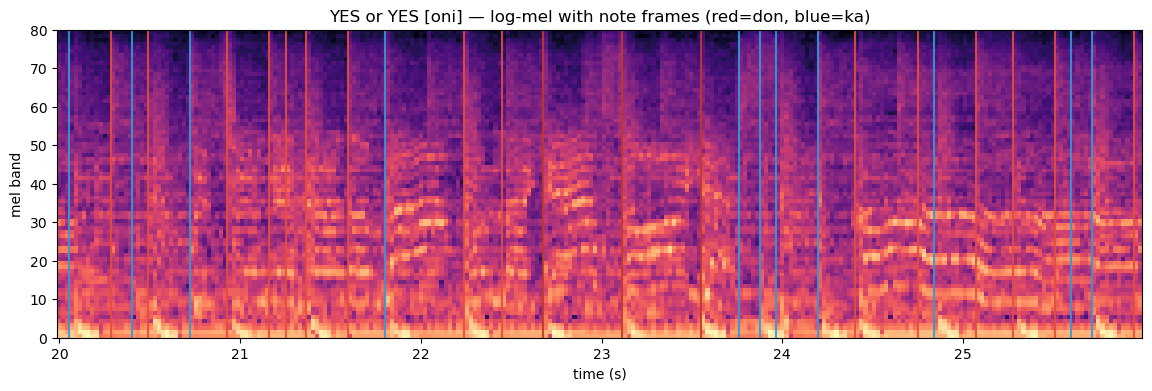

In [7]:
def onset_flux_ratio(feats, notes):
    flux = np.r_[0, np.maximum(np.diff(feats, axis=0), 0).sum(1)]
    m = min(len(feats), len(notes))
    onset = np.isin(notes[:m].argmax(1), [1, 2, 3, 4])
    return flux[:m][onset].mean() / flux[:m].mean()

print(f"flux at onset frames / mean flux: {onset_flux_ratio(song_feats, note_frames):.2f}")

t0, t1 = 20.0, 26.0
f0, f1 = int(t0 * 1000 // FRAME_MS), int(t1 * 1000 // FRAME_MS)
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(song_feats[f0:f1].T, origin="lower", aspect="auto", cmap="magma",
          extent=[f0 * FRAME_MS / 1000, f1 * FRAME_MS / 1000, 0, N_MELS])
colors = {1: "#e74c3c", 2: "#3498db", 3: "#c0392b", 4: "#1f5f8b", 5: "#f1c40f", 6: "#2ecc71"}
lab = note_frames.argmax(1)
for f in range(f0, f1):
    if lab[f]:
        ax.axvline(f * FRAME_MS / 1000, color=colors[lab[f]], lw=1.5 if lab[f] < 5 else 0.6, alpha=0.9)
ax.set(xlabel="time (s)", ylabel="mel band", title=f"{meta['TITLE']} [{COURSE}] — log-mel with note frames (red=don, blue=ka)")
plt.show()

In [8]:
OUT_DIR.mkdir(exist_ok=True)
np.save(OUT_DIR / f"{SONG.stem} Input.npy", song_feats)                  # like TaikoNationV1/input_songs
np.save(OUT_DIR / f"{SONG.stem}_{COURSE}.npy", note_frames)             # like TaikoNationV1/input_charts_nr (padded)
np.savez_compressed(OUT_DIR / f"{SONG.stem}_{COURSE}_windows.npz", X=X, Y=Y)
print(sorted(p.name for p in OUT_DIR.iterdir()))

['YES or YES Input.npy', 'YES or YES_oni.npy', 'YES or YES_oni_windows.npz']


## Appendix: the shipped TaikoNation audio features are scrambled
If `TaikoNationV1/` sits next to this repo, this cell reloads a few of its songs. It compares the rows as stored with the rows after undoing the lexicographic chunk order ("x 1.wav", "x 10.wav", "x 100.wav", …) that `os.listdir()` gives on Windows. With the un-scrambled order, adjacent frames are much more correlated, and chart onsets line up with spectral flux. The model was trained on the stored order.

In [9]:
TN = Path("../../TaikoNationV1")
if TN.exists():
    def adjacent_corr(a):
        a = (a - a.mean(0)) / (a.std(0) + 1e-9)
        return np.mean((a[1:] * a[:-1]).mean(1))

    songs = {p.name.split()[0]: p for p in (TN / "input_songs").iterdir()}
    for chart in sorted((TN / "input_charts_nr").iterdir())[:5]:
        s = np.load(songs[chart.name.split("_")[0]]).astype(np.float64)
        c = np.load(chart)
        n = len(s)
        lex = sorted(range(n), key=lambda i: f"{i + 1}.wav")
        unscramble = np.empty(n, int)
        unscramble[lex] = np.arange(n)
        print(f"{chart.name[:40]:40s} adj-corr {adjacent_corr(s):.2f} -> {adjacent_corr(s[unscramble]):.2f} | "
              f"onset flux ratio {onset_flux_ratio(s, c):.2f} -> {onset_flux_ratio(s[unscramble], c):.2f}")
else:
    print("TaikoNationV1 not found at", TN.resolve())

1009290_Mizutama_Nor+YUC'e_PolkaDot.npy  adj-corr 0.71 -> 0.82 | onset flux ratio 1.05 -> 2.33
1010280_Sentou!DenshoushaHigana_Kageyama adj-corr 0.49 -> 0.79 | onset flux ratio 0.99 -> 2.36
1010291_StardustPrism_AA...HisuiChazuke. adj-corr 0.48 -> 0.95 | onset flux ratio 0.99 -> 2.31
1013247_REGGAETONBUTITHASAMENBREAKS_ulko adj-corr 0.68 -> 0.82 | onset flux ratio 1.01 -> 1.66
1030563_Dstorv_Feryquitous_Efflorescence adj-corr 0.67 -> 0.92 | onset flux ratio 1.02 -> 1.94
